In [1]:
import numpy as np,pandas as pd, seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#question 1

data = {
    'customer_id': [101, 101, 102, 102, 103],
    'purchase_amount': [500, 700, 400, 600, 800],
    'date': ['2025-01-10', '2025-01-20', '2025-02-05',
             '2025-02-15', '2025-01-25']
}


df = pd.DataFrame(data)

df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

avg_monthly_spending = (
    df.groupby(['customer_id','month'])['purchase_amount'].sum().groupby('customer_id').mean()
)

print(avg_monthly_spending)

customer_id
101    1200.0
102    1000.0
103     800.0
Name: purchase_amount, dtype: float64


In [ ]:
# question 2



df=sns.lod_dataset('titanic')
# df.info()
before = (df.isnull().sum())

for col in df.columns:
    if df[col].dtype in ['int64','float64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col].mode()
        df[col] = df[col].fillna(df[col].mode()[0])

after = df.isnull().sum()

comparison = pd.DataFrame([before,after], index=['before','after'])
print("Missing values comparision")
comparison


Missing values comparision


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
before,0,0,0,27,0,0,0,1,0,0,0,102,2,1,1
after,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [24]:
#question 3

employees = pd.DataFrame({
    'name':['Amit','Riya','John','Sara'],
    'department':['IT','HR','IT','IT'],
    'salary':[70000,50000,65000,55000]
})


result = employees[(employees['department']=='IT') & (employees['salary']> 60000)]

result = result.sort_values(by='salary')

print(result)


   name department  salary
2  John         IT   65000
0  Amit         IT   70000


| Operation | Use For                                         |                                                |
| --------- | ----------------------------------------------- | ---------------------------------------------- |
| `and`     | Single booleans (`True and False`)              |                                                |
| `or`      | Single booleans (`True or False`)               |                                                |
| `&`       | Pandas Series / NumPy arrays (element-wise AND) |                                                      | `                                               | Pandas Series / NumPy arrays (element-wise OR) |
| `~`       | Pandas Series / NumPy arrays (NOT)              |                                                |


In [15]:
#question 4
import yfinance as yf

ticker = yf.Ticker('AAPL')

apple_data = ticker.history(period='3mo')
# print(apple_data.isnull().sum())
# print(apple_data.info())

mean_opening_price = apple_data['Open'].mean()
median_closing_price = apple_data['Close'].median()
std_dev_high = apple_data['High'].std()


print("Apple data summary for last 3 months:\n")
print("Mean opening price: ", mean_opening_price)
print("Median closing price: ", median_closing_price)
print("Std dev in High price: ", std_dev_high)

Apple data summary for last 3 months:

Mean opening price:  297.9391384621141
Median closing price:  298.11000061035156
Std dev in High price:  16.373486556310283


In [16]:
#question 5

sales = pd.DataFrame({
    'region':['North','North','South','South'],
    'product':['A','B','A','B'],
    'sales':[1000,1500,2000,2500]
})

pivot = pd.pivot_table(
    sales,
    values='sales',
    index='region',
    columns = 'product',
    aggfunc='sum'

)

print(pivot)

product     A     B
region             
North    1000  1500
South    2000  2500


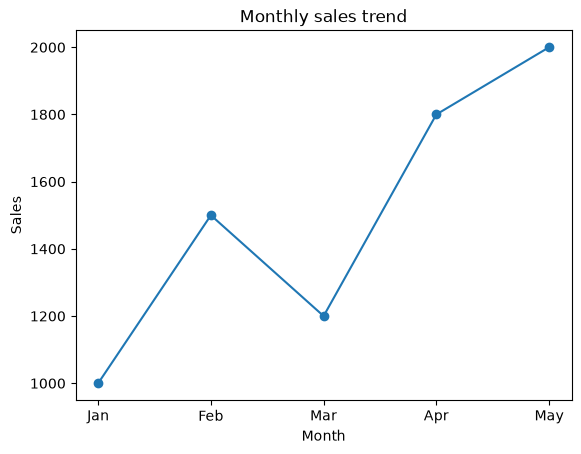

In [19]:
sales= pd.DataFrame(
    {
    'month':['Jan','Feb','Mar','Apr','May'],
    'sales':[1000,1500,1200,1800,2000]
}
)

plt.plot(sales['month'], sales['sales'],marker='o')
plt.title('Monthly sales trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

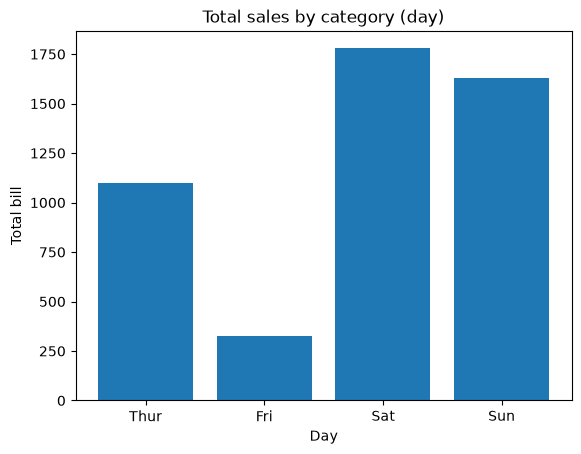

In [21]:
#question 7
tips = sns.load_dataset('tips')

category_sales = tips.groupby('day')['total_bill'].sum()

plt.bar(category_sales.index,
        category_sales.values)


plt.title("Total sales by category (day)")
plt.xlabel("Day")
plt.ylabel('Total bill')
plt.show()

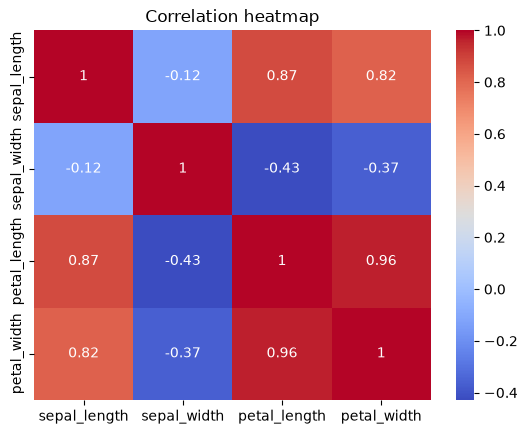

In [31]:
#question 8
iris = sns.load_dataset('iris')

corr = iris.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation heatmap')
plt.show()


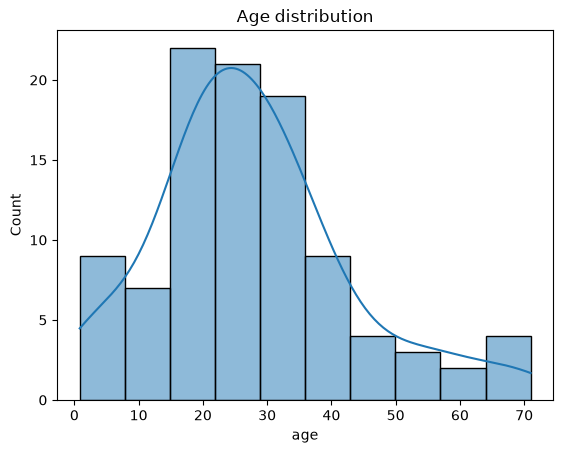

In [33]:
#question 9

titanic = sns.load_dataset('titanic')

sns.histplot(
    titanic['age'].dropna(),
    bins=10,
    kde=True
)

plt.title('Age distribution')
plt.show()

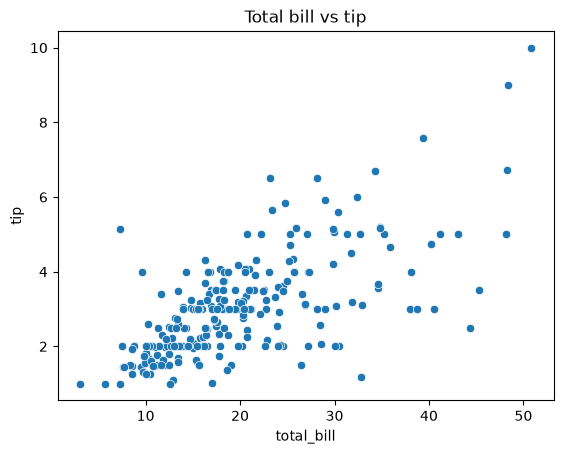

In [34]:
#question 10

sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip'
)

plt.title('Total bill vs tip')
plt.show()